This notebook trains 2 machine learning models.

The preprocessing of the transcription data includes:
- Removing the clinically irrelevant stopwords from the data
- Word embeddings is built by a custom fasttext model

The ML pipeline is structured like this:
- Split the data into a training and testing dataset.
- Have a grid search CV of a linear SVC pipeline and a multinomial logistic regression
- Determine the model with the best training matrix and fit it on the tes dataset.
- Predict using the test dataset and determine the validity of the model.

In [1]:
# Import the required packages
import re

import numpy as np
import pandas as pd

In [2]:
# Load the required data
top_mtsamples = pd.read_csv("../data/top_mtsamples.csv")

In [3]:
# Carry out text preprocessing
# Load custom clinical stopwords
with open('../data/clinical-stopwords.txt', 'r') as file:
    custom_stopwords = set(file.read().splitlines())

def clean_and_tokenize(text):
    """Lowercase, remove punctuation/numbers, remove stopwords. No lemmatization."""
    if not isinstance(text, str):
        return []
    
    tokens = re.findall(r'\b[a-z]+\b', text.lower())
    return [word for word in tokens if word not in custom_stopwords]

print("Tokenizing texts for FastText...")
top_mtsamples['fasttext_tokens'] = top_mtsamples['transcription'].apply(clean_and_tokenize)

Tokenizing texts for FastText...


In [4]:
# Import the library required to build a fasttext vectorizer
from sklearn.base import BaseEstimator, TransformerMixin
from gensim.models import FastText

In [5]:
# Build a custom fasttext vectorizer
class AverageFastTextVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, vector_size=100, window=5, min_count=2, epochs=10, min_n=3, max_n=6):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs
        self.min_n = min_n
        self.max_n = max_n
        self.model = None

    def fit(self, X, y=None):
        # FastText handles multiprocessing internally. 
        # Setting workers=4 takes advantage of a MacBook's multi-core architecture.
        self.model = FastText(
            sentences=X, 
            vector_size=self.vector_size, 
            window=self.window, 
            min_count=self.min_count,
            epochs=self.epochs,
            min_n=self.min_n,
            max_n=self.max_n,
            workers=4 
        )
        return self

    def transform(self, X, y=None):
        doc_vectors = []
        for doc in X:
            valid_words = [self.model.wv[word] for word in doc if word in self.model.wv]
            if valid_words:
                doc_vectors.append(np.mean(valid_words, axis=0))
            else:
                doc_vectors.append(np.zeros(self.vector_size))
        
        return np.array(doc_vectors)

In [6]:
# Import the libraries required for splitting, training and testing
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import LinearSVC
import warnings


In [7]:
# Splitting data
# Define features and target
X_ft = top_mtsamples['fasttext_tokens']
y_ft = top_mtsamples['medical_specialty_clean']

# Train/Test Split (30% holdout)
X_train_ft, X_test_ft, y_train_ft, y_test_ft = train_test_split(
    X_ft, y_ft, 
    test_size=0.30, 
    random_state=42, 
    stratify=y_ft
)

In [8]:
# Run the FastText vectorizer
# Instantiate the vectorizer (using default or best parameters found earlier)
print("Training FastText model and extracting embeddings...")
ft_vectorizer = AverageFastTextVectorizer(
    vector_size=100, 
    window=5, 
    min_count=2, 
    min_n=3, 
    max_n=6
)

# Fit FastText on training data and transform it into average vectors ONCE
X_train_embedded = ft_vectorizer.fit_transform(X_train_ft)

# Transform the test data to be held for final evaluation
X_test_embedded = ft_vectorizer.transform(X_test_ft)

Training FastText model and extracting embeddings...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Fine tune the hyperparamters using GridSearchCV and then train the model.

In [ ]:
# Define the hyperparameter grids for the classifiers
svc_param_grid = [
    {
        # Standard L2 regularization testing both loss functions
        'penalty': ['l2'], 
        'loss': ['hinge', 'squared_hinge'], 
        'C': [0.1, 0.5, 1.0, 5.0, 10.0], 
        'dual': ['auto']
    },
    {
        # L1 regularization (Lasso - forces feature selection) requires dual=False
        'penalty': ['l1'], 
        'loss': ['squared_hinge'], 
        'C': [0.1, 0.5, 1.0, 5.0, 10.0],
        'dual': [False]
    }
]

# LogisticRegression hyperparamters
logreg_param_grid = [
    {
        # Standard L2 penalty
        'penalty': ['l2'], 
        'solver': ['lbfgs', 'saga'], 
        'C': [0.1, 0.5, 1.0, 5.0, 10.0],
    },
    {
        # L1 penalty (Lasso)
        'penalty': ['l1'], 
        'solver': ['saga'], 
        'C': [0.1, 0.5, 1.0, 5.0, 10.0],
    }
]

# Suppress convergence warnings during the grid search
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Tune LinearSVC
print("Running GridSearchCV for LinearSVC...")
svc_grid = GridSearchCV(
    estimator=LinearSVC(class_weight='balanced', random_state=42, max_iter=3000),
    param_grid=svc_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
svc_grid.fit(X_train_embedded, y_train_ft)

# 2. Tune Logistic Regression
print("Running GridSearchCV for Logistic Regression...")
logreg_grid = GridSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced', 
        random_state=42, 
        max_iter=3000
    ),
    param_grid=logreg_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
logreg_grid.fit(X_train_embedded, y_train_ft)

# 3. Compare the optimized results
print("\n--- Optimized Cross-Validation Results ---")
print(f"Best LinearSVC F1-Macro: {svc_grid.best_score_:.4f}")
print("LinearSVC Best Params:", svc_grid.best_params_)

print(f"\nBest LogReg F1-Macro:    {logreg_grid.best_score_:.4f}")
print("LogReg Best Params:", logreg_grid.best_params_)


--- Optimized Cross-Validation Results ---
Best LinearSVC F1-Macro: 0.5228
LinearSVC Best Params: {'C': 1.0, 'dual': False, 'loss': 'squared_hinge', 'penalty': 'l1'}

Best LogReg F1-Macro:    0.5194
LogReg Best Params: {'C': 0.5, 'penalty': 'l1', 'solver': 'saga'}


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [15]:
# 1. Instantiate the winning model with the optimized hyperparameter
final_svc_model = LinearSVC(
    C=1.0, 
    dual=False,
    loss='squared_hinge',
    penalty='l1',
    class_weight='balanced', 
    random_state=42, 
    max_iter=3000
)

# 2. Fit the model on the full training embeddings
print("Fitting the final LinearSVC model...")
final_svc_model.fit(X_train_embedded, y_train_ft)

# 3. Generate predictions on the holdout test embeddings
print("Generating predictions on test data...")
y_pred_final = final_svc_model.predict(X_test_embedded)

# 4. Print the final classification report
print("\n--- Final Test Set Evaluation ---")
print(classification_report(y_test_ft, y_pred_final))

Fitting the final LinearSVC model...
Generating predictions on test data...

--- Final Test Set Evaluation ---
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.49      0.60      0.54       111
          Gastroenterology       0.45      0.57      0.50        67
          General Medicine       0.65      0.82      0.72        78
                 Neurology       0.50      0.72      0.59        67
   Obstetrics / Gynecology       0.48      0.72      0.57        46
                Orthopedic       0.48      0.64      0.55       107
                 Radiology       0.40      0.29      0.34        82
                   Surgery       0.66      0.37      0.48       327
                   Urology       0.47      0.60      0.52        47

                  accuracy                           0.53       932
                 macro avg       0.51      0.59      0.53       932
              weighted avg       0.55      0.53      0.52       932



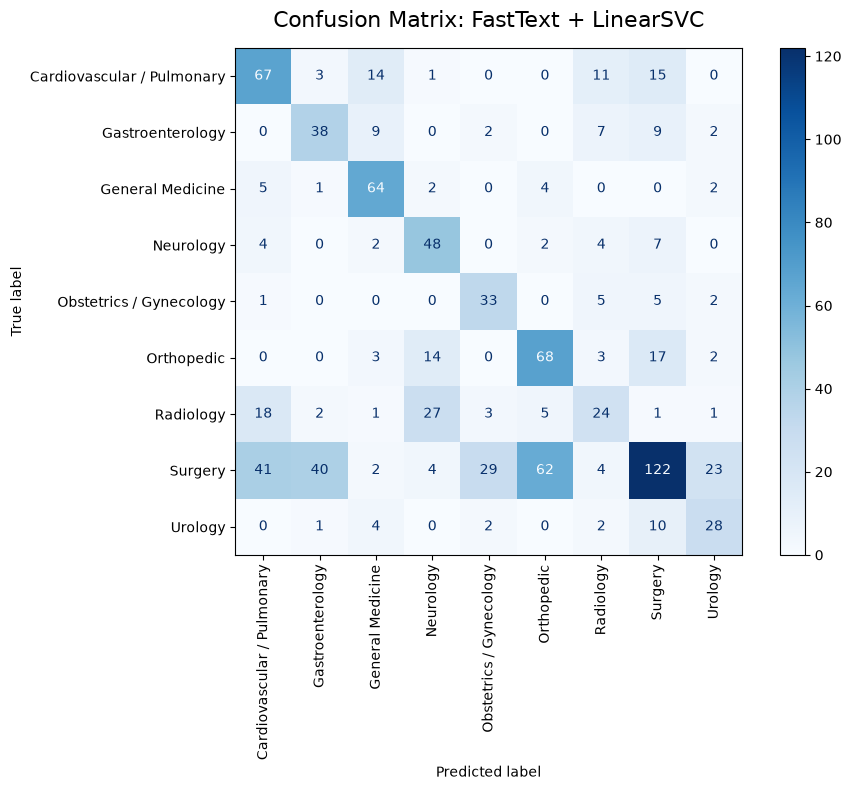

In [17]:
# 5. Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))

# Calculate and display the matrix
cm = confusion_matrix(y_test_ft, y_pred_final, labels=final_svc_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_svc_model.classes_)

# Apply a clean colormap and rotate the x-axis labels so they do not overlap
disp.plot(cmap='Blues', ax=ax, xticks_rotation=90)

# Add titles and formatting
plt.title('Confusion Matrix: FastText + LinearSVC', fontsize=16, pad=15)
plt.tight_layout()

# Render the plot
plt.show()